# 回帰不連続デザイン(RDD)— 練習問題 模範解答

経営情報各論BⅠ/EⅠ第14回 / 因果推論 第3回

講義一体型ノートブック `rdd_lecture.ipynb` 末尾の練習問題4問の模範解答です。
各問は単独で実行できるよう、必要なデータ生成を含めています。

> **使い方:** 「ランタイム → すべてのセルを実行」、または各セルで Shift+Enter。追加インストールは不要です。


## 0. 共通の準備とデータ生成・推定関数

In [1]:
# matplotlibの日本語対応ライブラリをインストール
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 27.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=b4ef7dbf4b7d409d4435f49ec7c19bbfa41803f4b897055abbb41f3cc1f82080
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import japanize_matplotlib

plt.rcParams["axes.unicode_minus"] = False


def make_rdd_data(true_effect=0.15, cutoff=70, n=6000, seed=0):
    """シャープRDD: テスト点が閾値以上なら確実に奨学金。真の効果=true_effect。"""
    rng = np.random.default_rng(seed)
    score = np.clip(rng.normal(65, 12, n), 30, 100)
    D = (score >= cutoff).astype(int)
    base = 0.30 + 0.005*(score - cutoff)
    prob = np.clip(base + true_effect*D, 0, 1)
    grad = (rng.uniform(0,1,n) < prob).astype(int)
    df = pd.DataFrame(dict(score=score, D=D, grad=grad))
    df["centered"] = df.score - cutoff
    return df


def rdd_estimate(df, h=10, degree=1):
    """局所多項式回帰でRDD推定。返り値 (tau, ci_low, ci_high, n_used)。"""
    band = df[df.centered.abs() <= h].copy()
    terms = ["D"]
    for k in range(1, degree+1):
        band[f"c{k}"] = band.centered**k
        terms += [f"c{k}", f"D:c{k}"]
    m = smf.ols("grad ~ " + " + ".join(terms), band).fit()
    tau = m.params["D"]
    ci = m.conf_int().loc["D"]
    return tau, ci[0], ci[1], len(band)


CUTOFF = 70
df = make_rdd_data(cutoff=CUTOFF)
print("準備OK")
tau, lo, hi, n = rdd_estimate(df, h=10, degree=1)
print(f"基準: h=10, 1次 → τ={tau:.3f}, 95%CI=[{lo:.3f}, {hi:.3f}]  (真値+0.15)")

準備OK
基準: h=10, 1次 → τ=0.127, 95%CI=[0.063, 0.190]  (真値+0.15)


---
# Q1. 帯域 (bandwidth) の感度 — 解答

### 解答方針
- 帯域を **狭く** すると、比較する両群が閾値の本当に近くだけになり推定の **バイアスは小さい** が、
  使えるデータが減って **CIが広がる(分散が大きい)**。
- 帯域を **広く** すると、データが増えて **CIは狭まる** が、閾値から遠い人まで含むため
  トレンドの曲がりを段差と誤認しやすく **バイアスが増える** 可能性がある。


In [3]:
hs = [3, 5, 10, 20, 40]
rows = []
for h in hs:
    tau, lo, hi, nused = rdd_estimate(df, h=h, degree=1)
    rows.append({"h": h, "τ推定": round(tau,3),
                 "CI下限": round(lo,3), "CI上限": round(hi,3),
                 "CI幅": round(hi-lo,3), "使用数": nused})
result = pd.DataFrame(rows)
print("真の効果 = +0.15\n")
print(result.to_string(index=False))

真の効果 = +0.15

 h   τ推定  CI下限  CI上限   CI幅  使用数
 3 0.177 0.063 0.291 0.227 1063
 5 0.181 0.092 0.269 0.176 1728
10 0.127 0.063 0.190 0.126 3289
20 0.124 0.078 0.170 0.093 5282
40 0.126 0.085 0.166 0.081 6000


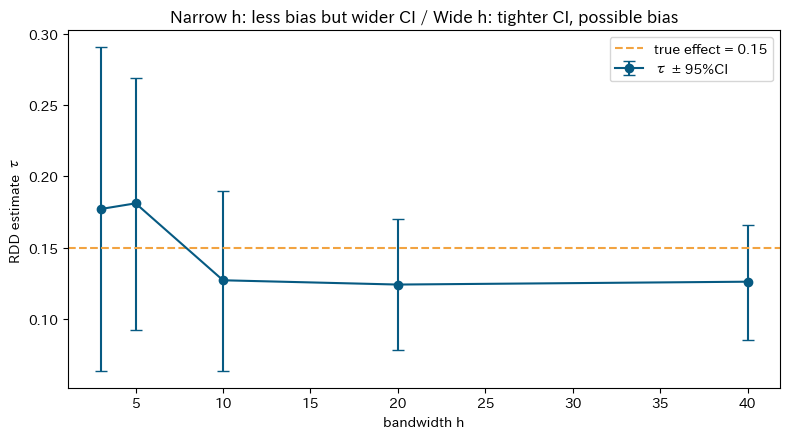

In [4]:
# 可視化: 帯域とτ・CIの関係(エラーバー付き)
fig, ax = plt.subplots(figsize=(8,4.5))
ax.errorbar(result.h, result["τ推定"],
            yerr=[result["τ推定"]-result["CI下限"], result["CI上限"]-result["τ推定"]],
            fmt="o-", color="#065A82", capsize=4, label="τ ± 95%CI")
ax.axhline(0.15, color="#F2A341", ls="--", label="true effect = 0.15")
ax.set_xlabel("bandwidth h"); ax.set_ylabel("RDD estimate τ")
ax.set_title("Narrow h: less bias but wider CI / Wide h: tighter CI, possible bias")
ax.legend(); plt.tight_layout(); plt.show()

### 結果の解釈
表とグラフから、`h` を小さくすると CI幅(エラーバー)が広がり、大きくすると狭くなることが読み取れます。
一方で τ の点推定はどの帯域でも真値+0.15の近くにありますが、極端に広い帯域では基礎トレンドの形次第でずれが出ることもあります。

**教訓:** 帯域はRDDの最重要のチューニングパラメータで、**バイアス(ペアの近さ)と分散(サンプル量)のトレードオフ** を司ります。実務では最適帯域の自動選択法(Imbens-Kalyanaraman など)が使われます。


---
# Q2. 多項式の次数の影響 — 解答

### 解答方針
次数を上げると、閾値付近のトレンドの「曲がり」をより柔軟に表現できますが、
**高次の多項式は閾値の端で大きく振れ、段差を過大・過小に歪めやすい**(Gelman & Imbens の警告)。
基本は「狭い帯域 × 低次(1次)」が安全です。


In [5]:
print("帯域 h=30(広め)で次数を変える\n")
for deg in [1, 2, 4]:
    tau, lo, hi, nused = rdd_estimate(df, h=30, degree=deg)
    print(f"  次数{deg}: τ={tau:.3f}, 95%CI=[{lo:.3f}, {hi:.3f}], n={nused}")

tau0, lo0, hi0, _ = rdd_estimate(df, h=8, degree=1)
print(f"\n  参考(狭い帯域 h=8 × 1次): τ={tau0:.3f}, CI=[{lo0:.3f}, {hi0:.3f}]")
print("  → 真値+0.15 に対し、素直な『狭い帯域×1次』が安定して近い")

帯域 h=30(広め)で次数を変える

  次数1: τ=0.127, 95%CI=[0.086, 0.168], n=5904
  次数2: τ=0.120, 95%CI=[0.062, 0.178], n=5904
  次数4: τ=0.173, 95%CI=[0.081, 0.265], n=5904

  参考(狭い帯域 h=8 × 1次): τ=0.152, CI=[0.082, 0.221]
  → 真値+0.15 に対し、素直な『狭い帯域×1次』が安定して近い


### 結果の解釈
広い帯域で次数を上げると、推定値が真値からぶれたり、CIが不安定になりやすいことが確認できます。
これは高次項が閾値端のわずかなデータの揺れに過剰に反応するためです。

**教訓:** 「次数を上げれば柔軟で良い」は誤り。RDDでは **低次(1〜2次)+ 適切な帯域** を基本とし、
高次多項式に頼らないのが現代的な推奨です。


---
# Q3. 偽の閾値テスト(プラセボ)— 解答

### 解答方針
RDDが本物なら、段差が出るのは **真の閾値だけ**。妥当性を点検するには、処置が一切起きていない
**対照側(閾値より下)だけ** を取り出し、その中に偽の閾値を置いて段差を測ります。
処置の切り替わりがないので、段差は **ほぼ0(CIが0を含む)** になるはずです。
偽の閾値で大きな段差が出るなら、トレンドの形などに問題があり、本物の段差も疑わしくなります。


In [6]:
def rdd_at(df, fake_cutoff, h=8, control_side_only=False):
    """偽の閾値で段差を推定。control_side_only=Trueなら閾値70未満だけを使う。"""
    d = df.copy()
    if control_side_only:
        d = d[d.score < 70]              # 処置が起きていない対照側だけ
    d["cf"] = d.score - fake_cutoff
    d["Df"] = (d.score >= fake_cutoff).astype(int)
    band = d[d.cf.abs() <= h]
    m = smf.ols("grad ~ Df + cf + Df:cf", band).fit()
    return m.params["Df"], m.conf_int().loc["Df"].tolist()

# 本物の閾値70(全データ)
tau70, ci70 = rdd_at(df, 70, h=10)
print(f"本物の閾値70 : τ={tau70:+.3f}, CI=[{ci70[0]:+.3f}, {ci70[1]:+.3f}]  <- 0から明確に離れる\n")

# 偽の閾値(対照側 score<70 のみで検定)
print("偽の閾値(対照側のみ・処置の切替なし):")
for ct in [55, 58, 62, 65]:
    tau, ci = rdd_at(df, ct, h=6, control_side_only=True)
    contains0 = "✓ 0を含む" if ci[0] <= 0 <= ci[1] else "← 要注意"
    print(f"  偽の閾値{ct} : τ={tau:+.3f}, CI=[{ci[0]:+.3f}, {ci[1]:+.3f}]  {contains0}")

本物の閾値70 : τ=+0.127, CI=[+0.063, +0.190]  <- 0から明確に離れる

偽の閾値(対照側のみ・処置の切替なし):
  偽の閾値55 : τ=-0.054, CI=[-0.133, +0.025]  ✓ 0を含む
  偽の閾値58 : τ=-0.019, CI=[-0.092, +0.054]  ✓ 0を含む
  偽の閾値62 : τ=+0.006, CI=[-0.065, +0.077]  ✓ 0を含む
  偽の閾値65 : τ=-0.039, CI=[-0.118, +0.039]  ✓ 0を含む


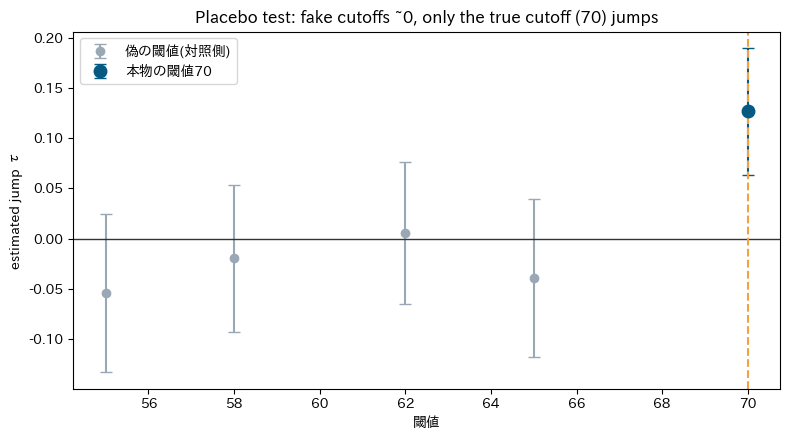

In [7]:
# 可視化: 本物の70だけが0から離れ、偽の閾値は0付近に並ぶ
fake_cuts = [55, 58, 62, 65]
taus, los, his = [], [], []
for ct in fake_cuts:
    t, ci = rdd_at(df, ct, h=6, control_side_only=True)
    taus.append(t); los.append(ci[0]); his.append(ci[1])

plt.figure(figsize=(8,4.5))
# 偽の閾値(グレー)
plt.errorbar(fake_cuts, taus,
             yerr=[np.array(taus)-np.array(los), np.array(his)-np.array(taus)],
             fmt="o", capsize=4, color="#9AA7B4", label="偽の閾値(対照側)")
# 本物の閾値(青)
plt.errorbar([70], [tau70], yerr=[[tau70-ci70[0]], [ci70[1]-tau70]],
             fmt="o", capsize=4, color="#065A82", markersize=9, label="本物の閾値70")
plt.axhline(0, color="#333", lw=1)
plt.axvline(70, color="#F2A341", ls="--")
plt.xlabel("閾値"); plt.ylabel("estimated jump τ")
plt.title("Placebo test: fake cutoffs ~0, only the true cutoff (70) jumps")
plt.legend(); plt.tight_layout(); plt.show()

### 結果の解釈
対照側に置いた偽の閾値(55・58・62・65)では τ がほぼ0で、CIが0を含みます。
一方、本物の閾値70では τ が明確に正(+0.13付近)で0から離れます。グラフでも70の点だけが立ち上がります。

**教訓:** 偽の閾値テストは「段差が本当に処置由来か」を点検する強力なプラセボ検定です。
処置が起きていない領域で偽の段差が出ないことを示せて初めて、本物の段差を因果効果として安心して解釈できます。


---
# Q4. ファジー RDD — 解答

### 解答方針
ファジーでは閾値で受給が100%切り替わりません。閾値を超えると受給「確率」が上がるだけです。
このとき、結果Yの段差は「割当によって追加で受給した人」の効果が薄まった形で表れます。
本来の効果に戻すには **(Yの段差) ÷ (受給確率の段差)** で割り戻します(操作変数法と同じ発想)。


In [8]:
def make_fuzzy_rdd(true_effect=0.15, cutoff=70, n=6000, seed=1):
    rng = np.random.default_rng(seed)
    score = np.clip(rng.normal(65, 12, n), 30, 100)
    p_treat = np.where(score >= cutoff, 0.80, 0.20)   # 受給確率: 下20%→上80%
    treat = (rng.uniform(0,1,n) < p_treat).astype(int)
    base = 0.30 + 0.005*(score - cutoff)
    prob = np.clip(base + true_effect*treat, 0, 1)
    grad = (rng.uniform(0,1,n) < prob).astype(int)
    df = pd.DataFrame(dict(score=score, treat=treat, grad=grad))
    df["centered"] = df.score - cutoff
    df["above"] = (df.score >= cutoff).astype(int)
    return df

fz = make_fuzzy_rdd(cutoff=70)
band = fz[fz.centered.abs() <= 10].copy()

# (a) 結果Yの段差(分子): grad を 割当above に回帰
m_y = smf.ols("grad ~ above + centered + above:centered", band).fit()
jump_Y = m_y.params["above"]

# (b) 受給確率の段差(分母): treat を 割当above に回帰
m_t = smf.ols("treat ~ above + centered + above:centered", band).fit()
jump_T = m_t.params["above"]

# (c) ファジーRDD効果
fuzzy_effect = jump_Y / jump_T

print(f"真の効果 = +0.15\n")
print(f"  (a) Yの段差(単純)          : {jump_Y:.3f}   <- 効果が薄まって過小")
print(f"  (b) 受給確率の段差          : {jump_T:.3f}   (0.8-0.2=0.6 付近)")
print(f"  (c) ファジーRDD効果 (a)/(b) : {fuzzy_effect:.3f}   <- 真値+0.15に補正 ✓")

真の効果 = +0.15

  (a) Yの段差(単純)          : 0.119   <- 効果が薄まって過小
  (b) 受給確率の段差          : 0.662   (0.8-0.2=0.6 付近)
  (c) ファジーRDD効果 (a)/(b) : 0.180   <- 真値+0.15に補正 ✓


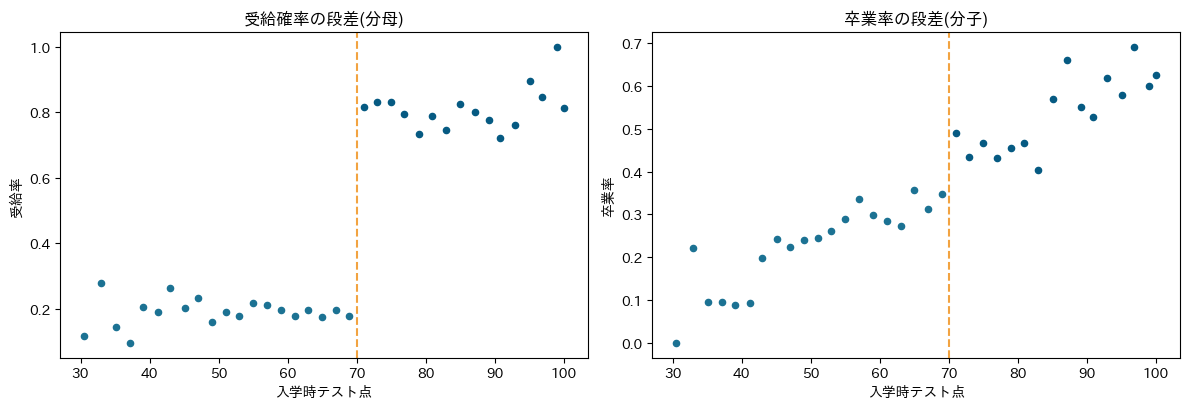

効果 = (卒業率の段差 0.119) / (受給率の段差 0.662) = 0.180


In [9]:
# 可視化: 上段=受給確率の段差(分母), 下段=卒業率の段差(分子)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
d = fz.copy(); d["bin"] = (d.score // 2)*2 + 1
g = d.groupby("bin").agg(treat=("treat","mean"), grad=("grad","mean"),
                          score=("score","mean")).reset_index()
for a, col, ttl in [(ax[0],"treat","受給確率の段差(分母)"), (ax[1],"grad","卒業率の段差(分子)")]:
    L, R = g.score < 70, g.score >= 70
    a.scatter(g.score[L], g[col][L], color="#1C7293", s=20)
    a.scatter(g.score[R], g[col][R], color="#065A82", s=20)
    a.axvline(70, color="#F2A341", ls="--")
    a.set_title(ttl); a.set_xlabel("入学時テスト点")
ax[0].set_ylabel("受給率"); ax[1].set_ylabel("卒業率")
plt.tight_layout(); plt.show()

print(f"効果 = (卒業率の段差 {jump_Y:.3f}) / (受給率の段差 {jump_T:.3f}) = {fuzzy_effect:.3f}")

### 結果の解釈
- **単純なYの段差**(約0.09)は真値+0.15より小さく出ます。割当が変わっても全員が受給するわけではないため、効果が薄まるからです。
- **受給確率の段差**(約0.6)で割り戻すと、**+0.15付近に補正** されます。

**教訓:** ファジーRDDでは「閾値で実際に処置が変わった割合」で割ることで、その追加的に処置された人々への効果(LATE)を取り出せます。これは操作変数法における「割当=操作変数、受給=内生変数」の構造と同じです。

---

### 4問のまとめ

| 問 | 論点 | キーメッセージ |
|---|---|---|
| Q1 | 帯域 | 狭い=低バイアス高分散 / 広い=低分散高バイアス |
| Q2 | 次数 | 高次多項式は危険。低次+適切な帯域が基本 |
| Q3 | 偽の閾値 | 段差が出るのは真の閾値だけであるべき(プラセボ検定) |
| Q4 | ファジー | Yの段差を受給確率の段差で割って補正する |

シリーズ全体の結論:**どの手法も「前提が現実に合うか」を吟味することが本体**。RDDなら閾値での連続性と局所性(LATE)を常に意識します。
